# Spaceship Titanic — Exploratory Data Analysis

Goal: predict `Transported` (boolean). Metric: **accuracy**.

This notebook answers eight EDA questions:

1. What is the target distribution?
2. Which features have missing values?
3. Which missing values mean *"None"* rather than missing data?
4. Which numerical features are skewed?
5. Which categorical features have high cardinality?
6. Which features are most strongly associated with the target `Transported`?
   *(adapted from the House Prices "correlated with SalePrice" question — our target is binary)*
7. Are there obvious outliers?
8. Are the train and test distributions similar?

Figures are saved to `reports/figures/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Resolve project root by walking up to the dir that contains ``src``.
here = Path.cwd()
PROJECT_ROOT = next(p for p in [here, *here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT))
from src import data

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

train = data.load_train()
test = data.load_test()
TARGET, ID = data.TARGET, data.ID_COL

SPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
NUM_COLS = ["Age"] + SPEND_COLS
CAT_COLS = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

print("train:", train.shape, "| test:", test.shape)
train.head()

train: (8693, 14) | test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 1. Target distribution

             count    pct
Transported              
True          4378  50.36
False         4315  49.64


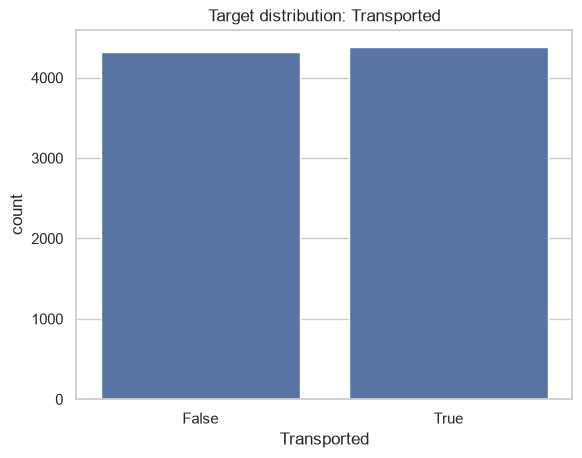

In [2]:
counts = train[TARGET].value_counts()
pct = (train[TARGET].value_counts(normalize=True) * 100).round(2)
print(pd.concat([counts.rename("count"), pct.rename("pct")], axis=1))

ax = sns.countplot(x=TARGET, data=train)
ax.set_title("Target distribution: Transported")
plt.savefig(FIG_DIR / "q1_target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

**Answer:** the classes are essentially balanced (~50/50), so accuracy is a sensible metric and no resampling is needed.

## 2. Which features have missing values?

In [3]:
miss = pd.DataFrame({
    "train_n": train.isna().sum(),
    "train_%": (train.isna().mean() * 100).round(2),
}).join(pd.DataFrame({
    "test_n": test.isna().sum(),
    "test_%": (test.isna().mean() * 100).round(2),
})).sort_values("train_%", ascending=False)
miss

,train_n,train_%,test_n,test_%
CryoSleep,217,2.50,93.0,2.17
ShoppingMall,208,2.39,98.0,2.29
VIP,203,2.34,93.0,2.17
HomePlanet,201,2.31,87.0,2.03
Name,200,2.30,94.0,2.20
Cabin,199,2.29,100.0,2.34
VRDeck,188,2.16,80.0,1.87
FoodCourt,183,2.11,106.0,2.48
Spa,183,2.11,101.0,2.36
Destination,182,2.09,92.0,2.15


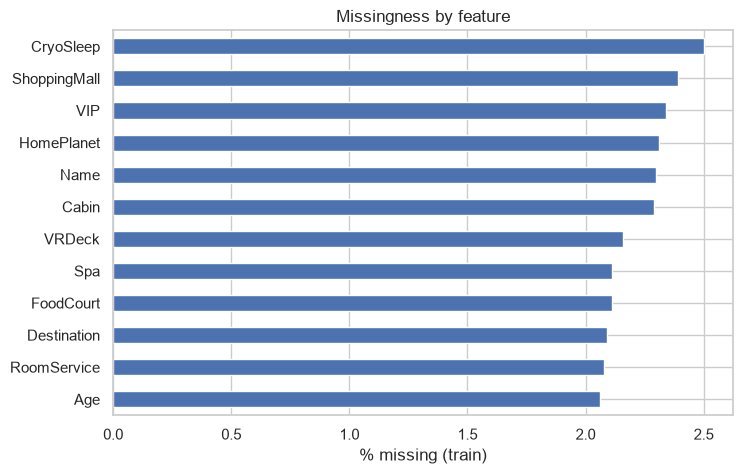

In [4]:
m = miss[miss["train_%"] > 0]
ax = m["train_%"].sort_values().plot.barh(figsize=(8, 5))
ax.set_xlabel("% missing (train)")
ax.set_title("Missingness by feature")
plt.savefig(FIG_DIR / "q2_missingness.png", dpi=120, bbox_inches="tight")
plt.show()

**Answer:** almost every column has ~2% missing values (scattered, not concentrated). `PassengerId` and `Transported` are complete. Missingness is similar in train and test.

## 3. Which missing values mean "None" rather than missing data?

The spend columns (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) are the candidates:
a passenger in `CryoSleep` is asleep for the voyage and cannot spend, so a missing spend there
plausibly means **0 (spent nothing)** rather than unknown. Let's check the evidence.

In [5]:
# Among confirmed CryoSleep passengers, what do the spend columns look like?
cryo = train[train["CryoSleep"] == True]
awake = train[train["CryoSleep"] == False]

print("Mean spend — CryoSleep=True:")
print(cryo[SPEND_COLS].mean().round(2))
print("\nMean spend — CryoSleep=False:")
print(awake[SPEND_COLS].mean().round(2))

frac_zero = (cryo[SPEND_COLS].fillna(0).sum(axis=1) == 0).mean()
print(f"\nFraction of CryoSleep=True passengers with total spend == 0: {frac_zero:.3f}")

Mean spend — CryoSleep=True:
RoomService     0.0
FoodCourt       0.0
ShoppingMall    0.0
Spa             0.0
VRDeck          0.0
dtype: float64

Mean spend — CryoSleep=False:
RoomService     350.15
FoodCourt       713.00
ShoppingMall    270.59
Spa             486.09
VRDeck          475.72
dtype: float64

Fraction of CryoSleep=True passengers with total spend == 0: 1.000


**Answer:**
- **Spend columns** — for CryoSleep passengers the spends are ~0 across the board, so a *missing* spend almost certainly means **None / 0**, not unknown. Fill these with 0 (especially when `CryoSleep` is True).
- **`CryoSleep`, `VIP`** — booleans where missing is genuinely unknown, though a sensible default (`VIP` → False, the dominant class) is reasonable.
- **`HomePlanet`, `Destination`, `Cabin`, `Age`, `Name`** — these are **true missing data** (no "None" semantics) and need imputation.

## 4. Which numerical features are skewed?

ShoppingMall    12.63
VRDeck           7.82
Spa              7.64
FoodCourt        7.10
RoomService      6.33
Age              0.42
dtype: float64


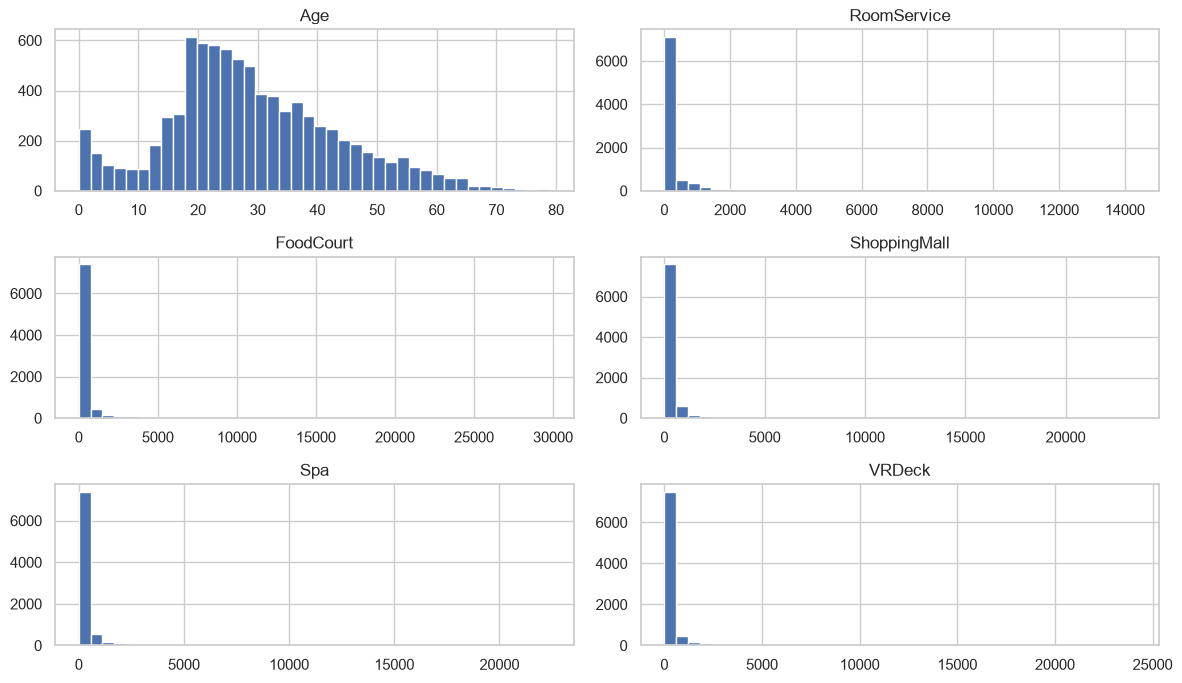

In [6]:
skew = train[NUM_COLS].skew().sort_values(ascending=False)
print(skew.round(2))

train[NUM_COLS].hist(bins=40, figsize=(12, 7))
plt.tight_layout()
plt.savefig(FIG_DIR / "q4_numeric_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

**Answer:** all five spend columns are **heavily right-skewed** (skew ≫ 1) — most passengers spend 0 with a long tail of big spenders. `Age` is roughly symmetric / mildly right-skewed. A `log1p` transform on the spend columns will help linear models.

## 5. Which categorical features have high cardinality?

In [7]:
card = train.drop(columns=[TARGET]).nunique().sort_values(ascending=False)
print(card)

PassengerId     8693
Name            8473
Cabin           6560
FoodCourt       1507
Spa             1327
VRDeck          1306
RoomService     1273
ShoppingMall    1115
Age               80
HomePlanet         3
Destination        3
CryoSleep          2
VIP                2
dtype: int64


**Answer:**
- **Very high cardinality (identifier-like):** `PassengerId` (8693), `Name` (8473), `Cabin` (6560) — do **not** one-hot these directly. They must be engineered: split `Cabin` into `Deck`/`Num`/`Side`, parse `PassengerId` into travel group + group size, optionally derive surname from `Name`.
- **Low cardinality (model-ready):** `HomePlanet` (3), `Destination` (3), `CryoSleep` (2), `VIP` (2) — safe to one-hot encode.

## 6. Which features are most strongly associated with `Transported`?

In [8]:
# Numeric features: point-biserial correlation with the binary target.
rows = []
for c in NUM_COLS:
    sub = train[[c, TARGET]].dropna()
    r, p = stats.pointbiserialr(sub[TARGET].astype(int), sub[c])
    rows.append((c, round(r, 3), p))
pb = pd.DataFrame(rows, columns=["feature", "pointbiserial_r", "p_value"])
pb = pb.reindex(pb["pointbiserial_r"].abs().sort_values(ascending=False).index)
print(pb.to_string(index=False))

     feature  pointbiserial_r       p_value
 RoomService           -0.245 3.400494e-116
         Spa           -0.221  9.275825e-95
      VRDeck           -0.207  4.989702e-83
         Age           -0.075  4.165051e-12
   FoodCourt            0.047  1.727865e-05
ShoppingMall            0.010  3.503013e-01


In [9]:
# Categorical features: transported rate within each category.
for c in CAT_COLS:
    print(f"--- {c} ---")
    print(train.groupby(c)[TARGET].mean().round(3))
    print()

--- HomePlanet ---
HomePlanet
Earth     0.424
Europa    0.659
Mars      0.523
Name: Transported, dtype: float64

--- CryoSleep ---
CryoSleep
False    0.329
True     0.818
Name: Transported, dtype: float64

--- Destination ---
Destination
55 Cancri e      0.610
PSO J318.5-22    0.504
TRAPPIST-1e      0.471
Name: Transported, dtype: float64

--- VIP ---
VIP
False    0.506
True     0.382
Name: Transported, dtype: float64



In [10]:
# Unified ranking via mutual information (ordinal-encoded, median/“missing”-filled).
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

X = train.drop(columns=[TARGET, ID, "Name", "Cabin"]).copy()
for c in X.columns:
    if X[c].dtype == bool or str(X[c].dtype) in ("object", "str", "string"):
        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X[c] = enc.fit_transform(X[[c]].astype(str))
    X[c] = X[c].fillna(X[c].median())

mi = pd.Series(
    mutual_info_classif(X, train[TARGET], random_state=0),
    index=X.columns,
).sort_values(ascending=False)
print(mi.round(4))

CryoSleep       0.1166
Spa             0.0844
RoomService     0.0776
VRDeck          0.0656
ShoppingMall    0.0483
FoodCourt       0.0418
HomePlanet      0.0154
Destination     0.0068
VIP             0.0053
Age             0.0040
dtype: float64


**Answer:** the strongest signals are:
- **`CryoSleep`** — by far the biggest driver: asleep passengers are transported at a much higher rate.
- **Spend columns** — `Spa`, `VRDeck`, `RoomService` correlate **negatively** (high spenders are transported less); `FoodCourt`/`ShoppingMall` are weaker/positive.
- **`HomePlanet`** (Europa transported most) and **`Destination`** carry moderate signal.
- `Age` and `VIP` are weak. (See the MI ranking for the combined ordering.)

## 7. Are there obvious outliers?

          Age  RoomService  FoodCourt  ShoppingMall      Spa   VRDeck
count  8514.0       8512.0     8510.0        8485.0   8510.0   8505.0
mean     28.8        224.7      458.1         173.7    311.1    304.9
std      14.5        666.7     1611.5         604.7   1136.7   1145.7
min       0.0          0.0        0.0           0.0      0.0      0.0
50%      27.0          0.0        0.0           0.0      0.0      0.0
90%      49.0        753.0     1026.0         619.6    732.0    732.6
99%      65.0       3096.2     8033.3        2333.4   5390.1   5646.7
max      79.0      14327.0    29813.0       23492.0  22408.0  24133.0


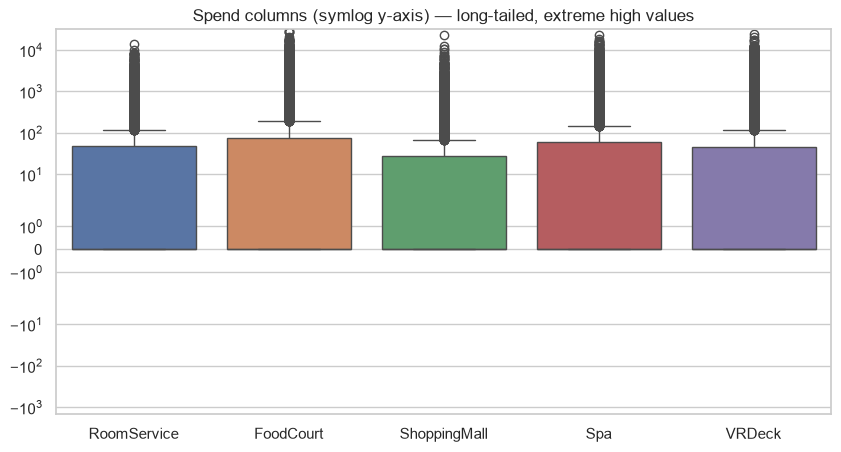

In [11]:
print(train[NUM_COLS].describe(percentiles=[0.5, 0.9, 0.99]).round(1))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=train[SPEND_COLS], ax=ax)
ax.set_yscale("symlog")
ax.set_title("Spend columns (symlog y-axis) — long-tailed, extreme high values")
plt.savefig(FIG_DIR / "q7_spend_outliers.png", dpi=120, bbox_inches="tight")
plt.show()

**Answer:** yes — the **spend columns** have extreme high-end outliers (99th percentile is small, but maxima run into the tens of thousands). These are genuine heavy-tailed spending, not data errors, so prefer a `log1p` transform / robust handling over deletion. `Age` has no problematic outliers (range ~0–79).

## 8. Are train and test distributions similar?

In [12]:
# Numeric: two-sample Kolmogorov–Smirnov test (large p-value => similar).
print("Numeric — KS test (train vs test):")
for c in NUM_COLS:
    s = stats.ks_2samp(train[c].dropna(), test[c].dropna())
    print(f"  {c:13s} KS={s.statistic:.3f}  p={s.pvalue:.3f}")

Numeric — KS test (train vs test):
  Age           KS=0.019  p=0.256
  RoomService   KS=0.008  p=0.991
  FoodCourt     KS=0.007  p=1.000
  ShoppingMall  KS=0.009  p=0.974
  Spa           KS=0.008  p=0.990
  VRDeck        KS=0.014  p=0.605


In [13]:
# Categorical: category proportions in train vs test.
for c in CAT_COLS:
    comp = pd.concat(
        [train[c].value_counts(normalize=True), test[c].value_counts(normalize=True)],
        axis=1, keys=["train", "test"],
    ).round(3)
    print(f"--- {c} ---")
    print(comp)
    print()

# Missingness comparison.
print("Missing % — train vs test:")
print(miss[["train_%", "test_%"]])

--- HomePlanet ---
            train   test
HomePlanet              
Earth       0.542  0.540
Europa      0.251  0.239
Mars        0.207  0.221

--- CryoSleep ---
           train   test
CryoSleep              
False      0.642  0.631
True       0.358  0.369

--- Destination ---
               train   test
Destination                
TRAPPIST-1e    0.695  0.706
55 Cancri e    0.211  0.201
PSO J318.5-22  0.094  0.093

--- VIP ---
       train   test
VIP                
False  0.977  0.982
True   0.023  0.018

Missing % — train vs test:
              train_%  test_%
CryoSleep        2.50    2.17
ShoppingMall     2.39    2.29
VIP              2.34    2.17
HomePlanet       2.31    2.03
Name             2.30    2.20
Cabin            2.29    2.34
VRDeck           2.16    1.87
FoodCourt        2.11    2.48
Spa              2.11    2.36
Destination      2.09    2.15
RoomService      2.08    1.92
Age              2.06    2.13
PassengerId      0.00    0.00
Transported      0.00     NaN


**Answer:** train and test look like the **same distribution** — KS statistics are small with non-significant p-values, categorical proportions match closely, and missingness rates are comparable. No covariate shift, so a standard CV split should generalize to the test set.

## Summary

| # | Question | Finding |
|---|----------|---------|
| 1 | Target distribution | ~50/50 balanced; accuracy is appropriate |
| 2 | Missing values | ~2% scattered across most columns; `PassengerId`/`Transported` complete |
| 3 | Missing = "None" | Spend columns (esp. when `CryoSleep`) → fill 0; categoricals/`Age` are true missing |
| 4 | Skewed numerics | All 5 spend columns heavily right-skewed → `log1p`; `Age` ~symmetric |
| 5 | High cardinality | `PassengerId`, `Name`, `Cabin` (engineer, don't encode); rest low-card |
| 6 | Associated with target | `CryoSleep` strongest; spend cols (neg); `HomePlanet`/`Destination` moderate |
| 7 | Outliers | Heavy-tailed spend maxima (genuine) → transform, not delete; `Age` fine |
| 8 | Train vs test | Same distribution (KS + proportions + missingness) — no covariate shift |

**Next:** implement these decisions in `src/features.py` (Cabin/PassengerId parsing, spend `log1p` + 0-fill, encoders).